# Predictive Analytics: Support Vector Regression (SVM)

We predict taxi pickup demand (`Total_Trip_Start`) with an SVR, and we do it at **every spatial and
temporal granularity** the discretization in `1.4` produces — four spatial levels (H3 res-7, H3 res-8,
census tract, community area) crossed with two temporal levels (hourly, daily).

The question is not only "how well can an SVR predict demand", but **"at which granularity is demand
predictable at all?"** A res-8 hexagon-hour is empty 97% of the time; a community area over a whole
day is essentially never empty. Those two targets are not the same problem, and a model that looks
good on one may be worthless on the other.

For each of the eight levels we search four feature sets, pick a winner on the validation split, and
evaluate it once on the held-out test split. Everything is collected into a `bundles` dictionary so
the levels can be compared against each other at the end.

In [1]:
import gc
import itertools
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET = "Total_Trip_Start"
SPLIT_DIR = Path("..") / "data" / "prediction_split"
MODELS_DIR = Path("..") / "models"
SVR_DIR = MODELS_DIR / "svr"
PRED_DIR = MODELS_DIR / "predictions"

# Training budget. SVR is O(n^2) to fit and O(n_SV * n) to predict, so the raw splits (up to 6.2M
# training rows) are far out of reach. We fit on a small balanced sample and select on a validation
# subsample; only the winning model per level touches the full test split.
N_SCAN = 4_000       # per class, for the kernel scan  -> 8k rows
N_GRID = 8_000       # per class, for the grid search  -> 16k rows
N_VAL_SUBSAMPLE = 50_000

## 1. The eight levels

Each split lives at `data/prediction_split/<spatial>/<temporal>/{train,val,test}.parquet`, and the
spatial level determines the name of the key column. This registry mirrors `POI_LEVELS` in
`3.1 FeatureEngineering.ipynb`.

In [2]:
SPATIAL_LEVELS = {
    "h3_7":      "h3_index_7",
    "h3_8":      "h3_index_8",
    "census":    "geoid10",
    "community": "commarea",
}
TEMPORAL_LEVELS = ["hourly", "daily"]

LEVELS = list(itertools.product(SPATIAL_LEVELS, TEMPORAL_LEVELS))


def load_splits(spatial, temporal):
    """Load train/val/test for one (spatial, temporal) level."""
    base = SPLIT_DIR / spatial / temporal
    return tuple(pd.read_parquet(base / f"{s}.parquet") for s in ("train", "val", "test"))


# Overview of what we are about to train on. The zero share is the headline number: it is what makes
# the fine levels hard and the coarse ones easy.
overview = []
for spatial, temporal in LEVELS:
    df = pd.read_parquet(SPLIT_DIR / spatial / temporal / "train.parquet",
                         columns=[SPATIAL_LEVELS[spatial], TARGET])
    overview.append({
        "spatial": spatial, "temporal": temporal,
        "units": df[SPATIAL_LEVELS[spatial]].nunique(),
        "train rows": len(df),
        "mean demand": df[TARGET].mean(),
        "zero %": (df[TARGET] == 0).mean() * 100,
    })
    del df

pd.DataFrame(overview).round(2)

,spatial,temporal,units,train rows,mean demand,zero %
0,h3_7,hourly,119,1230936,2.45,93.60
1,h3_7,daily,119,51289,58.91,78.97
2,h3_8,hourly,441,4561704,0.66,96.92
3,h3_8,daily,441,190071,15.90,89.03
4,census,hourly,600,6206400,0.49,97.05
5,census,daily,600,258600,11.68,89.67
6,community,hourly,77,796488,8.38,42.49
7,community,daily,77,33187,201.14,0.58


## 2. Feature sets

Four candidate feature sets per level, as before: a `basic` calendar + location + history block, then
POI counts and weather layered on top.

One thing has to change relative to the old notebook: **the daily grids have no hour features.** A
daily row is floored to midnight, so `hour_sin`/`hour_cos` would be constants. The feature set is
therefore derived from the temporal level rather than being a single global list.

(`distance_to_loop` was called `scikit_distance_to_loop` in the previous version of `3.1`; the column
was renamed and the old notebook has been reading a column that no longer exists.)

In [3]:
HOUR = ["hour_sin", "hour_cos"]                    # hourly grids only
CALENDAR = ["month_sin", "month_cos", "is_weekend",
            "is_holiday", "is_near_holiday", "day_of_week"]
LOCATION = ["lat", "lon", "distance_to_loop"]
HISTORY = ["base_demand"]                          # train-only historical mean, computed in 3.1

POI_COLS = ["poi_cat_automotive", "poi_cat_civic_community", "poi_cat_education",
            "poi_cat_entertainment", "poi_cat_finance", "poi_cat_food_drink", "poi_cat_grocery",
            "poi_cat_health", "poi_cat_leisure_sports", "poi_cat_lodging", "poi_cat_nightlife",
            "poi_cat_services", "poi_cat_shopping", "poi_cat_transport"]
WEATHER = ["2m_temp_c", "total_precip_mm", "snow_cov", "snow_depth", "wind_speed"]


def feature_sets(temporal):
    """The four candidate feature sets for a given temporal level."""
    basic = (HOUR if temporal == "hourly" else []) + CALENDAR + LOCATION + HISTORY
    return {
        "basic": basic,
        "basic+poi": basic + POI_COLS,
        "basic+weather": basic + WEATHER,
        "basic+poi+weather": basic + POI_COLS + WEATHER,
    }


for temporal in TEMPORAL_LEVELS:
    sizes = {name: len(f) for name, f in feature_sets(temporal).items()}
    print(f"{temporal:7s} {sizes}")

hourly  {'basic': 12, 'basic+poi': 26, 'basic+weather': 17, 'basic+poi+weather': 31}
daily   {'basic': 10, 'basic+poi': 24, 'basic+weather': 15, 'basic+poi+weather': 29}


## 3. Pipeline

Conventions carried over from `3.5 RainySundayDemandSVR.ipynb`:

- **Balanced sample.** At res-8 hourly the target is 96.9% zeros; a uniform sample would be almost
  all zeros and the SVR would learn to predict nothing. We take all non-zero rows up to a cap plus an
  equal number of zeros. Where a level is *not* zero-inflated (`community/daily` is only 0.6% zeros)
  the zero class simply runs out and the sample is non-zero-heavy — that is the correct behaviour.
- **log1p target.** Demand is counts with a long right tail. We fit on `log1p(y)` and invert with
  `expm1`, clipped at zero.
- **Scaler fit on the full training split**, never on val or test.
- **Metrics in count space**, not log space, so MAE is "trips per cell-period".
- **Two baselines on every table**: always-zero, and `base_demand` (the historical mean for that
  cell/hour-of-day/weekend profile, computed on train only in `3.1`). Without them the numbers are
  meaningless — when 97% of rows are zero, predicting zero already scores a respectable MAE.

In [4]:
LOG_CEILING = 20.0   # expm1(20) ~ 4.9e8 pickups in one cell-period: already absurd


def to_counts(pred_log):
    """Invert log1p and clip negative demand to 0.

    The log prediction is clipped first. An unbounded linear kernel can predict a log-demand of
    several hundred, and expm1 of that is +inf -- which then propagates into r2_score as a crash
    rather than a bad score. Clipping keeps the linear kernel's failure *finite and reportable*
    without touching any prediction a sane model would make.
    """
    return np.clip(np.expm1(np.clip(pred_log, -LOG_CEILING, LOG_CEILING)), 0, None)


def score(y_true, pred_counts, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, pred_counts),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred_counts)),
        "R2": r2_score(y_true, pred_counts),
    }


def balanced_sample(df, n_per_class, seed=RANDOM_STATE):
    """All non-zero rows (capped) plus an equal number of zero rows, shuffled.

    Where a level is not zero-inflated the zero class runs out and min() caps it -- the sample is then
    simply non-zero-heavy, which is what we want.
    """
    nz = df[df[TARGET] > 0]
    z = df[df[TARGET] == 0]
    return pd.concat([
        nz.sample(n=min(n_per_class, len(nz)), random_state=seed),
        z.sample(n=min(n_per_class, len(z)), random_state=seed),
    ]).sample(frac=1, random_state=seed)


def skill(model_metrics, baseline_metrics):
    """Fraction of the baseline's error the model removes. 0 = no better than baseline, 1 = perfect.

    Raw MAE cannot be compared across levels -- mean demand is 0.73 per cell-hour at h3_8/hourly but
    213 per area-day at community/daily, a 300x scale gap, so the finest grid would always 'win' on
    MAE simply by having less to be wrong about. Skill is scale-free: it asks whether the SVR beats
    the historical-mean baseline ON ITS OWN GROUND, which is comparable between levels.
    """
    return {
        "skill_MAE": 1 - model_metrics["MAE"] / baseline_metrics["MAE"],
        "skill_RMSE": 1 - model_metrics["RMSE"] / baseline_metrics["RMSE"],
    }

### Kernel scan, then grid search

Two stages, both fit on the balanced sample:

1. **Kernel scan** — `linear`, `poly`, `rbf` at fixed `C=1, gamma="scale"`, scored by R² on the
   validation subsample.
2. **Grid search** — `GridSearchCV` over `C` and `gamma` (plus `degree` if `poly` won), 3-fold,
   scoring `neg_mean_absolute_error`.

Expect the **linear kernel to score catastrophically** (R² in the thousands negative). That is not a
bug: a linear model in log space is unbounded, and `expm1` turns a moderately wrong log prediction
into an enormous count. It is retained deliberately, because it is the cleanest demonstration in the
whole report of *why* the kernel trick is needed here.

In [5]:
KERNELS = ["linear", "poly", "rbf"]


def find_best_kernel(Xs, ys, X_val, y_val):
    """Scan kernels at fixed hyperparameters; pick by validation R2 in count space."""
    val_r2 = {}
    for kernel in KERNELS:
        svr = SVR(kernel=kernel, C=1.0, gamma="scale", cache_size=500)
        svr.fit(Xs, ys)
        val_r2[kernel] = r2_score(y_val, to_counts(svr.predict(X_val)))
        print(f"      SVR({kernel:6s}) val R2 = {val_r2[kernel]:12.4f}")
    best = max(val_r2, key=val_r2.get)
    print(f"      -> best kernel: {best}")
    return best, val_r2


def count_mae_scorer(estimator, X, y_log):
    """Grid-search score: MAE in COUNT space, not log space.

    The model is fitted on log1p(y) but judged on counts, and the two do not agree. Scoring the CV in
    log space (as the previous notebook did) selects hyperparameters that are mildly better on the log
    scale but ruinous after expm1: on community/daily it picked a degree-3 poly whose validation R2
    was -9.7e8. Scoring the thing we actually care about removes the mismatch.
    """
    return -mean_absolute_error(to_counts(y_log), to_counts(estimator.predict(X)))


def grid_search_svr(Xs, ys, kernel):
    """Tune C / gamma (and degree for poly) by 3-fold CV on the balanced sample."""
    param_grid = {"C": [1, 10, 50], "gamma": ["scale", 0.05, 0.2]}
    if kernel == "poly":
        param_grid["degree"] = [2, 3]

    grid = GridSearchCV(
        SVR(kernel=kernel, cache_size=500),
        param_grid, cv=3, scoring=count_mae_scorer, n_jobs=-1,
    )
    grid.fit(Xs, ys)
    print(f"      best params: {grid.best_params_}")
    return grid.best_estimator_, grid.best_params_


def train_feature_set(df_train, df_val_s, features, spatial, temporal, set_name):
    """Fit one (level, feature set) configuration and return its bundle."""
    # Fit the scaler on the FULL training split (no leakage), but only ever transform the small
    # frames we actually predict on -- the old notebook scaled all ~9M train rows and threw the
    # array away.
    scaler = StandardScaler().fit(df_train[features])
    X_val = scaler.transform(df_val_s[features])
    y_val = df_val_s[TARGET].values

    scan = balanced_sample(df_train, N_SCAN)
    best_kernel, kernel_r2 = find_best_kernel(
        scaler.transform(scan[features]), np.log1p(scan[TARGET].values), X_val, y_val)

    sample = balanced_sample(df_train, N_GRID)
    tuned, best_params = grid_search_svr(
        scaler.transform(sample[features]), np.log1p(sample[TARGET].values), best_kernel)

    val_metrics = score(y_val, to_counts(tuned.predict(X_val)),
                        f"SVR {spatial}/{temporal} ({set_name}, {best_kernel})")

    return {
        "model": tuned,
        "scaler": scaler,
        "features": features,
        "spatial": spatial,
        "temporal": temporal,
        "spatial_key": SPATIAL_LEVELS[spatial],
        "feature_set": set_name,
        "kernel": best_kernel,
        "kernel_r2": kernel_r2,
        "best_params": best_params,
        "target": TARGET,
        "transform": "log1p",
        "val_metrics": val_metrics,
    }

## 4. Training

One pass per level: load the splits once, train all four feature sets, pick the winner on validation,
evaluate that winner once on the full test split, save it, and free the frames before moving on.
(`census/hourly` alone is ~4.5 GB of splits, so holding all eight in memory is not an option.)

The result is `bundles`, keyed by `(spatial, temporal, feature_set)` — 32 entries.

This cell takes roughly 45 minutes; test prediction over 8M rows is the bulk of it.

In [6]:
#| label: tbl-svr-val-metrics
#| tbl-cap: "Validation performance per level: baselines vs. the tuned SVR for each feature set."
SVR_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

bundles = {}      # (spatial, temporal, feature_set) -> bundle
val_rows = []     # every candidate + baselines, per level
test_rows = []    # baselines + the winning model, per level

for spatial, temporal in LEVELS:
    print(f"\n{'=' * 70}\n{spatial} / {temporal}\n{'=' * 70}")
    df_train, df_val, df_test = load_splits(spatial, temporal)
    key = SPATIAL_LEVELS[spatial]

    # Model selection happens on a fixed validation subsample: predicting all 2.5M validation rows
    # for every one of the 4 candidates would dominate the runtime and change nothing.
    df_val_s = df_val.sample(n=min(N_VAL_SUBSAMPLE, len(df_val)), random_state=RANDOM_STATE)
    y_val_s = df_val_s[TARGET].values
    print(f"train {len(df_train):>9,} | val {len(df_val):>9,} (subsample {len(df_val_s):,}) "
          f"| test {len(df_test):>9,} | zeros {(df_train[TARGET] == 0).mean():.1%}")

    for name, metrics in [
        ("Baseline: always zero", score(y_val_s, np.zeros(len(y_val_s)), "Baseline: always zero")),
        ("Baseline: historical mean (base_demand)",
         score(y_val_s, df_val_s["base_demand"].values, "Baseline: historical mean (base_demand)")),
    ]:
        val_rows.append({"spatial": spatial, "temporal": temporal, **metrics})

    for set_name, features in feature_sets(temporal).items():
        print(f"\n   feature set: {set_name} ({len(features)} features)")
        bundle = train_feature_set(df_train, df_val_s, features, spatial, temporal, set_name)
        bundles[(spatial, temporal, set_name)] = bundle
        val_rows.append({"spatial": spatial, "temporal": temporal, **bundle["val_metrics"]})
        print(f"      val: MAE={bundle['val_metrics']['MAE']:.3f}  "
              f"R2={bundle['val_metrics']['R2']:.4f}")

    # --- winner for this level, chosen on validation R2; the test set is touched exactly once ---
    level_sets = {k[2]: b for k, b in bundles.items() if k[0] == spatial and k[1] == temporal}
    best_set = max(level_sets, key=lambda s: level_sets[s]["val_metrics"]["R2"])
    best = level_sets[best_set]
    print(f"\n   -> winner: {best_set} ({best['kernel']}); scoring on the full test split...")

    y_test = df_test[TARGET].values
    base_test = score(y_test, df_test["base_demand"].values, "Baseline: historical mean (base_demand)")
    zero_test = score(y_test, np.zeros(len(y_test)), "Baseline: always zero")
    test_pred = to_counts(best["model"].predict(best["scaler"].transform(df_test[best["features"]])))
    model_test = score(y_test, test_pred, f"SVR ({best_set}, {best['kernel']})")

    best["test_metrics"] = model_test
    best["baseline_test_metrics"] = base_test
    best["skill"] = skill(model_test, base_test)
    best["is_level_winner"] = True

    for m in (zero_test, base_test, model_test):
        test_rows.append({"spatial": spatial, "temporal": temporal, **m})

    print(f"      test: MAE={model_test['MAE']:.3f}  R2={model_test['R2']:.4f}  "
          f"skill vs base_demand: {best['skill']['skill_MAE']:+.1%} MAE")

    # --- persist the winner and its test predictions ---
    out_dir = SVR_DIR / spatial / temporal
    out_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(best, out_dir / "best.joblib")

    pd.DataFrame({
        key: df_test[key].values,
        "timestamp": df_test["timestamp"].values,
        "y_true": y_test,
        "y_pred": test_pred,
    }).to_csv(PRED_DIR / f"{spatial}_{temporal}.csv", index=False)

    del df_train, df_val, df_val_s, df_test, test_pred
    gc.collect()

print(f"\n\nTrained {len(bundles)} configurations across {len(LEVELS)} levels.")

val_metrics = (pd.DataFrame(val_rows)
               .set_index(["spatial", "temporal", "Model"])
               .round(4))
val_metrics


h3_7 / hourly
train 1,230,936 | val   494,088 (subsample 50,000) | test   739,704 | zeros 93.6%

   feature set: basic (12 features)


      SVR(linear) val R2 =    -163.4703


      SVR(poly  ) val R2 =       0.8270


      SVR(rbf   ) val R2 =       0.9140
      -> best kernel: rbf


      best params: {'C': 10, 'gamma': 'scale'}


...

      SVR(rbf   ) val R2 =       0.9033
      -> best kernel: rbf


      best params: {'C': 10, 'gamma': 'scale'}


      val: MAE=44.294  R2=0.9237

   -> winner: basic+poi (rbf); scoring on the full test split...


      test: MAE=48.054  R2=0.9391  skill vs base_demand: +9.0% MAE


Trained 32 configurations across 8 levels.


MAE  \
spatial   temporal Model                                                     
h3_7      hourly   Baseline: always zero                            3.0503   
                   Baseline: historical mean (base_demand)          1.0236   
                   SVR h3_7/hourly (basic, rbf)                     0.9528   
                   SVR h3_7/hourly (basic+poi, rbf)                 0.9490   
                   SVR h3_7/hourly (basic+weather, rbf)             1.0188   
                   SVR h3_7/hourly (basic+poi+weather, rbf)         1.0036   
          daily    Baseline: always zero                           71.6167   
                   Baseline: historical mean (base_demand)         18.0772   
                   SVR h3_7/daily (basic, rbf)                     15.0599   
                   SVR h3_7/daily (basic+poi, rbf)                 14.8816   
                   SVR h3_7/daily (basic+weather, rbf)             18.0446   
                   SVR h3_7/daily (basic+poi+weather, rbf)         17.1400   
h3_8      hourly   Baseline: always zero                            0.7768   
                   Baseline: historical mean (base_demand)          0.2994   
                   SVR h3_8/hourly (basic, rbf)                     0.3545   
                   SVR h3_8/hourly (basic+poi, rbf)                 0.3530   
                   SVR h3_8/hourly (basic+weather, rbf)             0.3773   
                   SVR h3_8/hourly (basic+poi+weather, rbf)         0.3653   
          daily    Baseline: always zero                           19.1863   
                   Baseline: historical mean (base_demand)          5.1226   
                   SVR h3_8/daily (basic, rbf)                      4.5412   
                   SVR h3_8/daily (basic+poi, rbf)                  4.5322   
                   SVR h3_8/daily (basic+weather, rbf)              5.8269   
                   SVR h3_8/daily (basic+poi+weather, rbf)          5.2827   
census    hourly   Baseline: always zero                            0.5831   
                   Baseline: historical mean (base_demand)          0.2414   
                   SVR census/hourly (basic, rbf)                   0.3116   
                   SVR census/hourly (basic+poi, rbf)               0.3111   
                   SVR census/hourly (basic+weather, rbf)           0.3239   
                   SVR census/hourly (basic+poi+weather, rbf)       0.3179   
          daily    Baseline: always zero                           14.0741   
                   Baseline: historical mean (base_demand)          3.8677   
                   SVR census/daily (basic, rbf)                    3.6490   
                   SVR census/daily (basic+poi, rbf)                3.5006   
                   SVR census/daily (basic+weather, rbf)            5.0516   
                   SVR census/daily (basic+poi+weather, rbf)        4.2710   
community hourly   Baseline: always zero                            9.6129   
                   Baseline: historical mean (base_demand)          2.9386   
                   SVR community/hourly (basic, rbf)                3.0843   
                   SVR community/hourly (basic+poi, rbf)            3.0392   
                   SVR community/hourly (basic+weather, rbf)        3.3487   
                   SVR community/hourly (basic+poi+weather, rbf)    3.2149   
          daily    Baseline: always zero                          231.0757   
                   Baseline: historical mean (base_demand)         41.7484   
                   SVR community/daily (basic, rbf)                41.8738   
                   SVR community/daily (basic+poi, rbf)            34.5404   
                   SVR community/daily (basic+weather, rbf)        56.8979   
                   SVR community/daily (basic+poi+weather, rbf)    44.2939   

                                                                      RMSE  \
spatial   temporal Model                                                     
h3_7      hour

## 5. Comparing the levels

Raw MAE is **not** comparable across levels. Mean demand runs from 0.73 trips per hexagon-hour at
`h3_8/hourly` to 213 trips per area-day at `community/daily` — a 300× gap. On raw MAE the finest grid
would always look best simply because there is less to be wrong about.

The **skill score** fixes this: `1 - MAE_model / MAE_base_demand`. It asks whether the SVR beats the
historical-mean baseline *on its own ground*, and that comparison transfers across levels. A skill of
0 means the model has learned nothing the historical average did not already know; negative means it
is actively worse.

In [7]:
#| label: tbl-svr-level-comparison
#| tbl-cap: "Winning SVR per level, with skill against the historical-mean baseline."
comparison = []
for (spatial, temporal), _ in ((lv, None) for lv in LEVELS):
    best = next(b for k, b in bundles.items()
                if k[0] == spatial and k[1] == temporal and b.get("is_level_winner"))
    comparison.append({
        "spatial": spatial,
        "temporal": temporal,
        "feature_set": best["feature_set"],
        "kernel": best["kernel"],
        "C": best["best_params"].get("C"),
        "gamma": best["best_params"].get("gamma"),
        "test_MAE": best["test_metrics"]["MAE"],
        "test_RMSE": best["test_metrics"]["RMSE"],
        "test_R2": best["test_metrics"]["R2"],
        "base_MAE": best["baseline_test_metrics"]["MAE"],
        "skill_MAE": best["skill"]["skill_MAE"],
        "skill_RMSE": best["skill"]["skill_RMSE"],
    })

level_comparison = pd.DataFrame(comparison).sort_values("skill_MAE", ascending=False)
level_comparison.to_csv(SVR_DIR / "level_comparison.csv", index=False)
level_comparison.round(4).reset_index(drop=True)

,spatial,temporal,feature_set,kernel,C,gamma,test_MAE,test_RMSE,test_R2,base_MAE,skill_MAE,skill_RMSE
0,h3_7,daily,basic,rbf,10,scale,19.8439,115.6312,0.9179,22.0992,0.1021,0.0946
1,community,daily,basic+poi,rbf,10,scale,48.0541,177.8371,0.9391,52.8156,0.0902,0.0817
2,h3_8,daily,basic+poi,rbf,10,scale,5.7656,37.8566,0.9140,6.2982,0.0846,0.1018
3,census,daily,basic+poi,rbf,10,scale,4.3974,29.4112,0.9089,4.6938,0.0632,0.0979
4,h3_7,hourly,basic,rbf,10,scale,1.0853,7.4107,0.8849,1.1519,0.0578,0.0960
5,community,hourly,basic,rbf,10,scale,3.2062,13.0699,0.8773,3.2476,0.0128,-0.0379
6,h3_8,hourly,basic,rbf,10,scale,0.3797,2.6234,0.8694,0.3427,-0.1080,0.0921
7,census,hourly,basic+weather,rbf,10,scale,0.3325,2.1809,0.8407,0.2642,-0.2584,0.0294


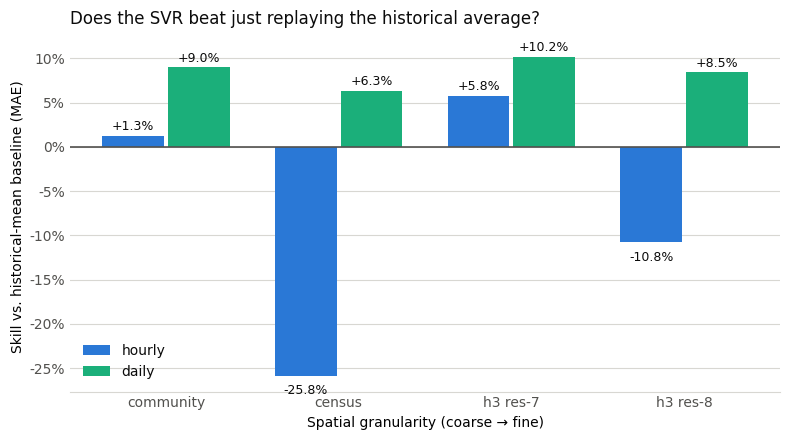

In [8]:
#| label: fig-svr-skill-by-level
#| fig-cap: "SVR skill against the historical-mean baseline, by spatial and temporal granularity. Positive means the model beats simply replaying the historical average for that cell; zero means it learned nothing new."
SERIES = {"hourly": "#2a78d6", "daily": "#1baf7a"}   # validated pair, worst adjacent CVD dE 73.6
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

order = ["community", "census", "h3_7", "h3_8"]      # coarse -> fine
skill_grid = (level_comparison
              .pivot(index="spatial", columns="temporal", values="skill_MAE")
              .reindex(order))

x = np.arange(len(order))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, temporal in enumerate(TEMPORAL_LEVELS):
    vals = skill_grid[temporal].to_numpy()
    pos = x + (i - 0.5) * width
    ax.bar(pos, vals, width * 0.94, label=temporal, color=SERIES[temporal], zorder=3)

    # Direct-label every bar: only 8 of them, and the aqua sits below 3:1 contrast on white, so the
    # palette's relief rule requires visible labels rather than colour alone.
    for p, v in zip(pos, vals):
        ax.annotate(f"{v:+.1%}", (p, v), textcoords="offset points",
                    xytext=(0, 4 if v >= 0 else -13), ha="center",
                    fontsize=9, color=INK)

ax.axhline(0, color=MUTED, lw=1.2, zorder=4)
ax.set_xticks(x, [o.replace("_", " res-") for o in order])
ax.set_ylabel("Skill vs. historical-mean baseline (MAE)")
ax.set_xlabel("Spatial granularity (coarse \u2192 fine)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED, length=0)
ax.legend(frameon=False, loc="best", labelcolor=INK)
ax.set_title("Does the SVR beat just replaying the historical average?",
             color=INK, fontsize=12, loc="left", pad=12)

plt.tight_layout()
plt.show()

## 6. What the comparison says

Read the skill column, not the MAE column. The MAE column tells you how big the cells are; the skill
column tells you whether the model is doing anything.

Points to check when reading the output above:

- **A skill near zero means the SVR has not beaten `base_demand`.** `base_demand` is just the mean of
  that cell's demand for that hour-of-day/weekend profile over the training period. It is a strong
  baseline precisely because taxi demand is overwhelmingly a function of *where* and *when* — which
  is what the historical mean already encodes.
- **The linear kernel's R² is catastrophic by construction**, not by accident: an unbounded linear
  prediction in log space becomes an astronomically large count after `expm1`. It is the argument for
  the kernel.
- Weather adds little at any level. That is consistent with `3.5`, where the weather-aware model was
  *worse* on validation than the weather-free one — the rain signal is real but small next to the
  spatio-temporal signal.

Artifacts written:

- `models/svr/<spatial>/<temporal>/best.joblib` — the winning bundle per level (model, scaler, feature
  list, kernel, params, val + test metrics, skill)
- `models/predictions/<spatial>_<temporal>.csv` — test predictions with the spatial key and timestamp,
  for `3.4` and `3.6`
- `models/svr/level_comparison.csv` — the table above

## 7. Which features actually earn their place?

The models above carry up to 31 features, and the level comparison already hints that most of them do
nothing: weather is selected at only one of eight levels, and the SVR barely beats a baseline built
from a *single* number per cell. So which features are actually carrying the prediction?

**The RBF kernel rules out the obvious answer.** `coef_` exists only for a linear SVR, and the kernel
scan showed the linear kernel is unusable here (R² ≈ −1400). Reading weights off a model that does not
work would tell us nothing, and that also rules out RFE, which needs the same coefficients. We are
left with model-agnostic methods, and we use two, because they answer different questions:

| method | the question it answers |
|---|---|
| **Permutation importance** | Does the *fitted* model rely on this feature? (shuffle it, measure how much MAE degrades) |
| **Drop-column ablation** | Would a model *trained without* it be worse? (refit, compare) |

The two diverge exactly when features are substitutable — and ours are, heavily.

### Why we permute in blocks, not one column at a time

Three groups here are near-redundant by construction:

- `lat`, `lon`, `distance_to_loop` — the distance is a deterministic function of the other two
- `hour_sin`, `hour_cos` — two halves of one cyclic encoding
- the 14 `poi_cat_*` columns — heavily co-occurring (see the Spearman heatmap in `1.3`)

Shuffle `lat` on its own and the model shrugs: `lon` and `distance_to_loop` still locate the cell.
Every column then looks unimportant while the group is essential — the classic failure of per-column
permutation under correlation. So we report **both**: per-column importance, and importance with each
block permuted *together* (one shuffled row order applied across the whole block, so the within-block
correlation survives and only the link to the target is broken). The gap between the two numbers is
itself the measurement of redundancy.

Importance is expressed as **% increase in count-space MAE** — the metric the model is actually judged
on. A feature worth 0% is a feature the model is not using.

In [9]:
# Feature blocks. Columns inside a block are correlated with each other; columns across blocks are
# (mostly) not. Permuting a block as a unit is what makes the importance of a redundant group visible.
FEATURE_BLOCKS = {
    "hour": HOUR,
    "calendar": CALENDAR,
    "location": LOCATION,
    "history (base_demand)": HISTORY,
    "poi": POI_COLS,
    "weather": WEATHER,
}

N_IMPORTANCE_ROWS = 8_000   # rows sampled from validation; predict cost is ~0.2 ms/row per pass
N_REPEATS = 3


def _mae(bundle, X, y):
    """Count-space MAE of a bundle on an already-assembled feature frame."""
    return mean_absolute_error(y, to_counts(bundle["model"].predict(bundle["scaler"].transform(X))))


def permutation_importance(bundle, df_eval, groups, n_repeats=N_REPEATS, seed=RANDOM_STATE):
    """Increase in MAE when each group of columns is shuffled together.

    Passing groups={col: [col] for col in features} gives ordinary per-column importance; passing the
    feature blocks gives the grouped version. Shuffling a group with ONE shared row order keeps the
    within-group correlation intact and destroys only the group's relationship to the target.
    """
    rng = np.random.default_rng(seed)
    X = df_eval[bundle["features"]].copy()
    y = df_eval[TARGET].values
    baseline = _mae(bundle, X, y)

    rows = []
    for name, cols in groups.items():
        cols = [c for c in cols if c in X.columns]      # a block may not be in this feature set
        if not cols:
            continue
        deltas = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[cols] = X[cols].to_numpy()[rng.permutation(len(X))]
            deltas.append(_mae(bundle, X_perm, y) - baseline)
        rows.append({
            "group": name,
            "n_cols": len(cols),
            "delta_MAE": float(np.mean(deltas)),
            "delta_MAE_std": float(np.std(deltas)),
            "pct_MAE_increase": float(np.mean(deltas)) / baseline * 100,
        })
    return pd.DataFrame(rows).sort_values("delta_MAE", ascending=False), baseline


def drop_column_ablation(bundle, df_train, df_eval, groups):
    """Refit the model without each block and measure how much worse validation MAE gets.

    Permutation asks whether the FITTED model uses a feature; ablation asks whether a model trained
    without it would be worse. They disagree when a dropped feature has a substitute the retrained
    model can lean on instead -- which is the whole question for a redundant feature set.

    The kernel and hyperparameters are held at the tuned values rather than re-searched, so the only
    thing that changes is the feature list.
    """
    y_eval = df_eval[TARGET].values
    params = {k: v for k, v in bundle["best_params"].items()}

    def fit_and_score(features):
        scaler = StandardScaler().fit(df_train[features])
        sample = balanced_sample(df_train, N_GRID)
        model = SVR(kernel=bundle["kernel"], cache_size=500, **params)
        model.fit(scaler.transform(sample[features]), np.log1p(sample[TARGET].values))
        pred = to_counts(model.predict(scaler.transform(df_eval[features])))
        return mean_absolute_error(y_eval, pred)

    full_mae = fit_and_score(bundle["features"])

    rows = []
    for name, cols in groups.items():
        remaining = [f for f in bundle["features"] if f not in cols]
        if len(remaining) == len(bundle["features"]) or not remaining:
            continue                                    # block absent, or would leave nothing
        mae = fit_and_score(remaining)
        rows.append({
            "dropped": name,
            "n_dropped": len(bundle["features"]) - len(remaining),
            "MAE_without": mae,
            "delta_MAE": mae - full_mae,
            "pct_MAE_increase": (mae - full_mae) / full_mae * 100,
        })
    return pd.DataFrame(rows).sort_values("delta_MAE", ascending=False), full_mae


In [10]:
#| label: tbl-svr-permutation
#| tbl-cap: "Grouped permutation importance of each feature block, per level: % increase in validation MAE when the block is shuffled together."
# Run both analyses on the WINNING model of each level. The splits are reloaded per level (ablation
# has to refit, so it needs the training data) and freed again. ~95 s per level.
perm_block_rows = []    # blocks, permuted together
perm_col_rows = []      # single columns, for the redundancy comparison
ablation_rows = []

for spatial, temporal in LEVELS:
    bundle = joblib.load(SVR_DIR / spatial / temporal / "best.joblib")
    df_train, df_val, _ = load_splits(spatial, temporal)
    df_eval = df_val.sample(n=min(N_IMPORTANCE_ROWS, len(df_val)), random_state=RANDOM_STATE)
    print(f"{spatial}/{temporal}: {bundle['feature_set']} ({len(bundle['features'])} features)")

    blocks, base_mae = permutation_importance(bundle, df_eval, FEATURE_BLOCKS)
    for r in blocks.to_dict("records"):
        perm_block_rows.append({"spatial": spatial, "temporal": temporal, **r})

    cols, _ = permutation_importance(bundle, df_eval, {c: [c] for c in bundle["features"]})
    for r in cols.to_dict("records"):
        perm_col_rows.append({"spatial": spatial, "temporal": temporal, **r})

    abl, full_mae = drop_column_ablation(bundle, df_train, df_eval, FEATURE_BLOCKS)
    for r in abl.to_dict("records"):
        ablation_rows.append({"spatial": spatial, "temporal": temporal, **r})

    top_perm = blocks.iloc[0]
    top_abl = abl.iloc[0]
    print(f"   relies most on: {top_perm['group']} (+{top_perm['pct_MAE_increase']:.0f}% MAE shuffled)"
          f"  |  actually needs most: {top_abl['dropped']} (+{top_abl['pct_MAE_increase']:.1f}% MAE dropped)")

    del df_train, df_val, df_eval
    gc.collect()

perm_blocks = pd.DataFrame(perm_block_rows)
perm_cols = pd.DataFrame(perm_col_rows)
ablation = pd.DataFrame(ablation_rows)

perm_blocks.to_csv(SVR_DIR / "permutation_importance_blocks.csv", index=False)
perm_cols.to_csv(SVR_DIR / "permutation_importance_columns.csv", index=False)
ablation.to_csv(SVR_DIR / "drop_column_ablation.csv", index=False)

# level x block matrices, used by the figure and the tables below
block_matrix = (perm_blocks
                .assign(level=perm_blocks.spatial + "/" + perm_blocks.temporal)
                .pivot(index="level", columns="group", values="pct_MAE_increase"))
ablation_matrix = (ablation
                   .assign(level=ablation.spatial + "/" + ablation.temporal)
                   .pivot(index="level", columns="dropped", values="pct_MAE_increase"))

block_matrix.round(1)


h3_7/hourly: basic (12 features)


   relies most on: history (base_demand) (+572% MAE shuffled)  |  actually needs most: history (base_demand) (+216.0% MAE dropped)
h3_7/daily: basic (10 features)


   relies most on: location (+6791% MAE shuffled)  |  actually needs most: history (base_demand) (+169.9% MAE dropped)


h3_8/hourly: basic (12 features)


   relies most on: history (base_demand) (+362% MAE shuffled)  |  actually needs most: history (base_demand) (+187.1% MAE dropped)
h3_8/daily: basic+poi (24 features)


...

   relies most on: history (base_demand) (+292% MAE shuffled)  |  actually needs most: history (base_demand) (+248.4% MAE dropped)
census/daily: basic+poi (24 features)


   relies most on: history (base_demand) (+53170% MAE shuffled)  |  actually needs most: calendar (+13.8% MAE dropped)
community/hourly: basic (12 features)


   relies most on: history (base_demand) (+985% MAE shuffled)  |  actually needs most: history (base_demand) (+53.6% MAE dropped)
community/daily: basic+poi (24 features)


   relies most on: history (base_demand) (+4989% MAE shuffled)  |  actually needs most: calendar (+25.5% MAE dropped)


group,calendar,history (base_demand),hour,location,poi,weather
level,,,,,,
census/daily,34.3,53169.9,NaN,169.9,51722.4,NaN
census/hourly,25.2,292.3,9.5,55.0,NaN,11.0
community/daily,50.7,4989.5,NaN,407.8,1584.0,NaN
community/hourly,34.0,984.7,35.9,674.8,NaN,NaN
h3_7/daily,159.8,4554.8,NaN,6791.4,NaN,NaN
h3_7/hourly,47.3,571.8,50.2,214.6,NaN,NaN
h3_8/daily,32.2,679.4,NaN,162.5,508.7,NaN
h3_8/hourly,25.7,362.4,12.5,53.8,NaN,NaN


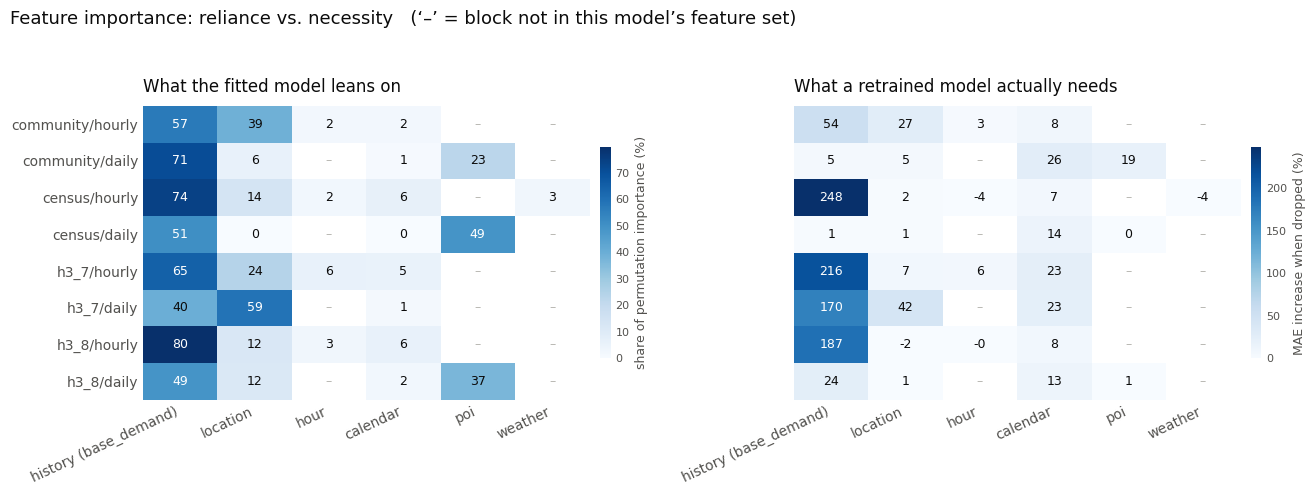

In [11]:
#| label: fig-svr-feature-importance
#| fig-cap: "Left: what the fitted model leans on (grouped permutation importance, as each block's share of the level's total). Right: what a retrained model actually needs (drop-column ablation, % increase in MAE when the block is removed). The two disagree sharply on base_demand — the fitted model depends on it almost entirely, yet a model refitted without it loses very little, because lat/lon/hour/day-of-week can reconstruct it."
BLOCK_ORDER = ["history (base_demand)", "location", "hour", "calendar", "poi", "weather"]
LEVEL_ORDER = [f"{s}/{t}" for s in ["community", "census", "h3_7", "h3_8"] for t in TEMPORAL_LEVELS]

# Permutation is reported as each block's SHARE of the level's total importance. The raw percentages
# are enormous (permuting base_demand can raise MAE by ~5000%, because a wrong value in log space
# explodes through expm1) and one column would swamp the colour scale. The share answers the question
# we care about -- how the model divides its reliance -- and is comparable across levels.
share = (block_matrix
         .div(block_matrix.sum(axis=1), axis=0)
         .mul(100)
         .reindex(index=LEVEL_ORDER, columns=BLOCK_ORDER))
abl = ablation_matrix.reindex(index=LEVEL_ORDER, columns=BLOCK_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)

for ax, M, title, unit in [
    (axes[0], share, "What the fitted model leans on", "share of permutation importance (%)"),
    (axes[1], abl, "What a retrained model actually needs", "MAE increase when dropped (%)"),
]:
    A = M.to_numpy(dtype=float)
    im = ax.imshow(A, cmap="Blues", aspect="auto", vmin=0)      # sequential: one hue, light -> dark
    ax.set_xticks(np.arange(len(BLOCK_ORDER)), BLOCK_ORDER, rotation=25, ha="right")
    ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

    # Label every cell. The numbers are the finding, and a ramp alone cannot separate "small" from
    # "zero" -- which is precisely the distinction this figure exists to show.
    vmax = np.nanmax(A) if np.isfinite(A).any() else 1.0
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            v = A[i, j]
            if np.isnan(v):
                ax.text(j, i, "–", ha="center", va="center", color="#b8b7b2", fontsize=9)
            else:
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                        color="#ffffff" if v > 0.55 * vmax else INK)

    cbar = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
    cbar.set_label(unit, color=MUTED, fontsize=9)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=MUTED, length=0, labelsize=8)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=10)

axes[0].set_yticks(np.arange(len(LEVEL_ORDER)), LEVEL_ORDER)

fig.suptitle("Feature importance: reliance vs. necessity   (‘–’ = block not in this model’s feature set)",
             color=INK, fontsize=13, x=0.01, ha="left")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


In [12]:
#| label: tbl-svr-ablation
#| tbl-cap: "Drop-column ablation: % change in validation MAE when each block is removed and the model refitted. Positive = the model is genuinely worse without it; ~0 or negative = the block is dead weight."
ablation_matrix.reindex(index=LEVEL_ORDER, columns=BLOCK_ORDER).round(1)


dropped,history (base_demand),location,hour,calendar,poi,weather
level,,,,,,
community/hourly,53.6,26.8,2.7,7.9,NaN,NaN
community/daily,4.6,5.4,NaN,25.5,19.0,NaN
census/hourly,248.4,1.5,-4.3,6.5,NaN,-4.5
census/daily,1.1,1.1,NaN,13.8,0.4,NaN
h3_7/hourly,216.0,6.9,6.5,23.3,NaN,NaN
h3_7/daily,169.9,42.3,NaN,22.7,NaN,NaN
h3_8/hourly,187.1,-1.9,-0.2,7.7,NaN,NaN
h3_8/daily,24.4,0.8,NaN,12.6,0.7,NaN


In [13]:
#| label: tbl-svr-redundancy
#| tbl-cap: "Redundancy check: importance of each block when its columns are permuted ONE AT A TIME and summed, versus permuted TOGETHER. A block worth far more together than apart is internally redundant."
# Sum of the single-column importances within a block vs. the block permuted as a unit. If the columns
# substitute for each other, shuffling them individually barely hurts (each has a stand-in) while
# shuffling them together does -- so together >> sum-of-parts is the signature of redundancy.
col_to_block = {c: b for b, cols in FEATURE_BLOCKS.items() for c in cols}

parts = (perm_cols
         .assign(level=perm_cols.spatial + "/" + perm_cols.temporal,
                 block=perm_cols.group.map(col_to_block))
         .groupby(["level", "block"])["pct_MAE_increase"].sum()
         .rename("sum_of_columns_separately"))

together = (perm_blocks
            .assign(level=perm_blocks.spatial + "/" + perm_blocks.temporal)
            .set_index(["level", "group"])["pct_MAE_increase"]
            .rename("block_permuted_together"))
together.index.names = ["level", "block"]

redundancy = (pd.concat([parts, together], axis=1)
              .dropna()
              .assign(redundancy_gap=lambda d: d.block_permuted_together - d.sum_of_columns_separately)
              .sort_values("redundancy_gap", ascending=False))

redundancy.round(2).head(15)


sum_of_columns_separately  \
level            block                                              
census/daily     poi                                      3041.23   
h3_7/daily       history (base_demand)                    4047.43   
community/daily  history (base_demand)                    4589.82   
community/hourly location                                  416.20   
h3_8/hourly      history (base_demand)                     355.34   
h3_7/hourly      history (base_demand)                     565.73   
census/hourly    weather                                    11.46   
                 history (base_demand)                     293.33   
community/hourly history (base_demand)                     987.63   
census/hourly    hour                                       12.86   
h3_8/daily       history (base_demand)                     684.89   
h3_8/hourly      hour                                       21.15   
census/daily     calendar                                   53.56   
h3_8/daily       calendar                                   55.40   
h3_7/hourly      hour                                       75.76   

                                        block_permuted_together  \
level            block                                            
census/daily     poi                                   51722.37   
h3_7/daily       history (base_demand)                  4554.84   
community/daily  history (base_demand)                  4989.48   
community/hourly location                                674.79   
h3_8/hourly      history (base_demand)                   362.36   
h3_7/hourly      history (base_demand)                   571.81   
census/hourly    weather                                  11.02   
                 history (base_demand)                   292.35   
community/hourly history (base_demand)                   984.73   
census/hourly    hour                                      9.48   
h3_8/daily       history (base_demand)                   679.44   
h3_8/hourly      hour                                     12.48   
census/daily     calendar                                 34.32   
h3_8/daily       calendar                                 32.23   
h3_7/hourly      hour                                     50.18   

                                        redundancy_gap  
level            block                                  
census/daily     poi                          48681.14  
h3_7/daily       history (base_demand)          507.41  
community/daily  history (base_demand)          399.66  
community/hourly location                       258.58  
h3_8/hourly      history (base_demand)            7.02  
h3_7/hourly      history (base_demand)            6.08  
census/hourly    weather                         -0.44  
                 history (base_demand)           -0.99  
community/hourly history (base_demand)           -2.89  
census/hourly    hour                            -3.38  
h3_8/daily       history (base_demand)           -5.44  
h3_8/hourly      hour                            -8.67  
census/daily     calendar                       -19.24  
h3_8/daily       calendar                       -23.17  
h3_7/hourly      hour                           -25.58